In [53]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

In [54]:
def tampil(img, title, rows, cols, position):
    plt.subplot(rows, cols, position)
    plt.imshow(img, cmap='gray')  
    plt.title(title)
    plt.axis('on')

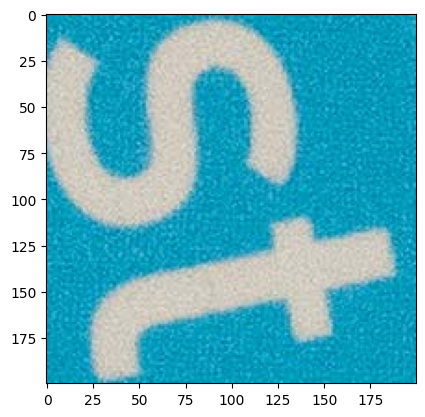

In [55]:
sate = cv.imread('iso6400raw.jpg')
sate = cv.cvtColor(sate, cv.COLOR_BGR2RGB)
tampil(sate, '', 1, 1, 1)


## Proses Read Citra Asli

Output menampilkan citra asli yang dibaca menggunakan `cv.imread()`. Diketahui nama file adalah `iso6400raw.jpg` mengindikasikan bahwa gambar ini diambil dengan *ISO 6400*, dimana sensitivitas cahayanya sangat tinggi pada kamera. ISO yang tinggi menyebabkan *noise* (bintik-bintik acak) yang sangat signifikan pada citra. Konversi BGR ke RGB dilakukan karena OpenCV secara default membaca gambar dalam format BGR. Tanpa konversi ini, warna gambar akan terlihat tidak natural (dominan kebiruan).
Fungsi `tampil()` menggunakan `cmap='gray'`, namun karena citra sudah berformat RGB (3 channel), parameter ini diabaikan oleh Matplotlib dan gambar tetap ditampilkan berwarna. Noise yang terlihat pada citra ini menjadi alasan mengapa pada tahap kedua dilakukan *median filtering* sebelum deteksi tepi, karena noise dapat memperburuk hasil deteksi tepi jika tidak dihilangkan terlebih dahulu.

In [56]:
def tresholding(img, batas):
    baris, kolom = img.shape
    canvas = np.zeros_like(img, dtype=np.uint8)
    for i in range(baris):
        for j in range(kolom):
            if img[i, j] > batas:
                canvas[i, j] = 255
            else:
                canvas[i, j] = 0
    return canvas

def normalize(img):
    img = np.abs(img)
    img = (img / img.max()) * 255
    return img.astype(np.uint8)

def convolution(img, kernel):

    size = kernel.shape[0]
    pad = size // 2

    h, w = img.shape
    hasil = np.zeros((h, w), dtype=np.float32)

    padded = np.zeros((h + 2*pad, w + 2*pad))
    padded[pad:pad+h, pad:pad+w] = img

    for i in range(h):
        for j in range(w):

            region = padded[i:i+size, j:j+size]

            hasil[i, j] = np.sum(region * kernel)

    return hasil

In [57]:
def sobel(img):

    sobel_x = np.array([
        [-1, 0, 1],
        [-2, 0, 2],
        [-1, 0, 1]
    ])

    sobel_y = np.array([
        [-1, -2, -1],
        [ 0,  0,  0],
        [ 1,  2,  1]
    ])

    gx = convolution(img, sobel_x)
    gy = convolution(img, sobel_y)
    hasil = np.abs(gx) + np.abs(gy)
    return normalize(hasil)

In [58]:
def filter(img, size, mode):
    height, width = img.shape
    pad = size // 2
    padded = np.pad(img, pad, mode='edge')
    canvas = np.zeros_like(img, dtype=np.uint8)

    match mode:
        case 'mean':
            area = size * size

            for i in range(height):
                for j in range(width):
                    region = padded[i:i+size, j:j+size]
                    canvas[i, j] = np.sum(region) / area

        case 'median':
            for i in range(height):
                for j in range(width):
                    region = padded[i:i+size, j:j+size]
                    canvas[i, j] = np.median(region)

        case 'mode':
            for i in range(height):
                for j in range(width):
                    region = padded[i:i+size, j:j+size]
                    values = region.ravel()
                    count = {}

                    for val in values:
                        if val in count:
                            count[val] += 1
                        else:
                            count[val] = 1
                    max_count = 0
                    mode_val = 0

                    for val, freq in count.items():
                        if freq > max_count:
                            max_count = freq
                            mode_val = val
                    canvas[i, j] = mode_val
    return canvas

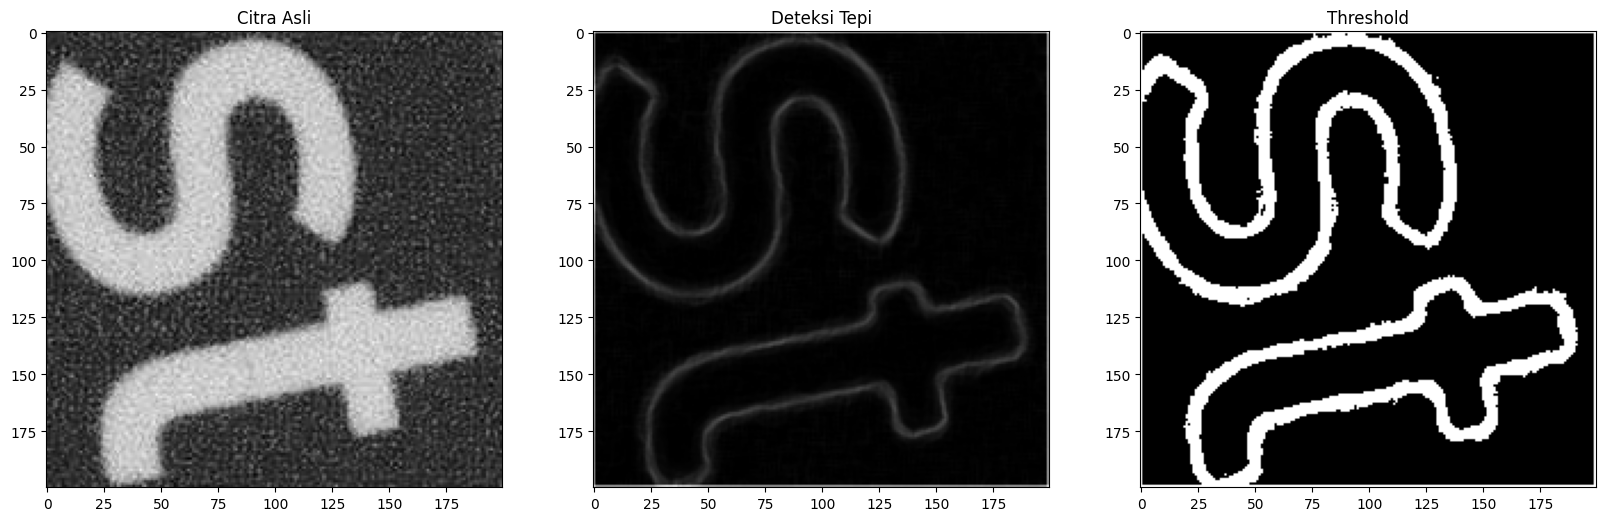

In [70]:
gray = cv.cvtColor(sate, cv.COLOR_RGB2GRAY)
med = filter(gray, 9, 'median')
sobelin = sobel(med)
trasholdd = tresholding(sobelin, 14)

plt.figure(figsize=(20, 10))
tampil(gray, "Citra Asli", 1, 3, 1)
tampil(sobelin, "Deteksi Tepi", 1, 3, 2)
tampil(trasholdd, "Threshold", 1, 3, 3)

## Analisis pipeline dari Citra Asli ke Deteksi Tepi kemudian Threshold

Output menampilkan tiga tahap pemrosesan secara berurutan:

### 1. Citra Asli (Grayscale)
`cv.cvtColor(sate, cv.COLOR_RGB2GRAY)` berfungsi untuk mengonversi citra RGB menjadi grayscale (1 channel) sehingga setiap piksel hanya memiliki satu nilai intensitas (0–255). Citra terlihat abu-abu dengan banyak noise berupa bintik-bintik halus akibat ISO tinggi.

### 2. Deteksi Tepi (Sobel)
Sebelum Sobel, diterapkan *median filter 9×9* (`filter(gray, 9, 'median')`). Dimana filter median berguna untuk menggantikan setiap piksel dengan nilai *median* dari tetangganya dalam window 9×9. Ini sangat efektif untuk menghilangkan *salt-and-pepper noise* karena median tidak terpengaruh oleh nilai ekstrem (noise). Operator `sobel` menghitung gradien intensitas pada arah horizontal (`Gx`) dan vertikal (`Gy`) menggunakan kernel 3×3. Hasil akhirnya adalah `|Gx| + |Gy|`, yang menonjolkan tepi objek.

### 3. Threshold (Nilai Batas = 14)
Nilai threshold `14` terbilang rendah, artinya hampir semua piksel yang mendeteksi perubahan intensitas sekecil apapun akan menjadi putih (255). Ini menyebabkan banyak tepi terdeteksi sekaligus, termasuk tepi-tepi kecil dari sisa noise. Hasilnya adalah citra biner yang menunjukkan seluruh tepi dari objek dalam gambar.

In [61]:
kernell = np.array([
    [0, 0, 1, 1, 1],
    [0, 0, 1, 1, 1],
    [1, 1, 1, 1, 1],
    [1, 1, 1, 0, 0],
    [1, 1, 1, 0, 0]
], dtype=np.uint8)

def dilasi(image, kernel):
    height, width = image.shape
    k_height, k_width = kernel.shape
    center_h = k_height // 2
    center_w = k_width // 2
    hasil = np.zeros((height, width), dtype=np.uint8)

    for i in range(center_h, height - center_h):
        for j in range(center_w, width - center_w):
            if image[i, j] == 255:
                for k in range(k_height):
                    for l in range(k_width):
                        if kernel[k, l] == 1:
                            hasil[i + k - center_h, j + l - center_w] = 255
    return hasil


def erosi(image, kernel):
    height, width = image.shape
    k_height, k_width = kernel.shape
    center = k_height // 2
    hasil = np.zeros((height, width))

    for i in range(center, height - center):
        for j in range(center, width - center):
            cocok = True
            for k in range(k_height):
                for l in range(k_width):
                    if kernel[k, l] == 1 and image[i + k - center, j + l - center] == 0:
                        cocok = False
                        break
                if not cocok:
                    break
            if cocok:
                hasil[i, j] = 255

    return hasil


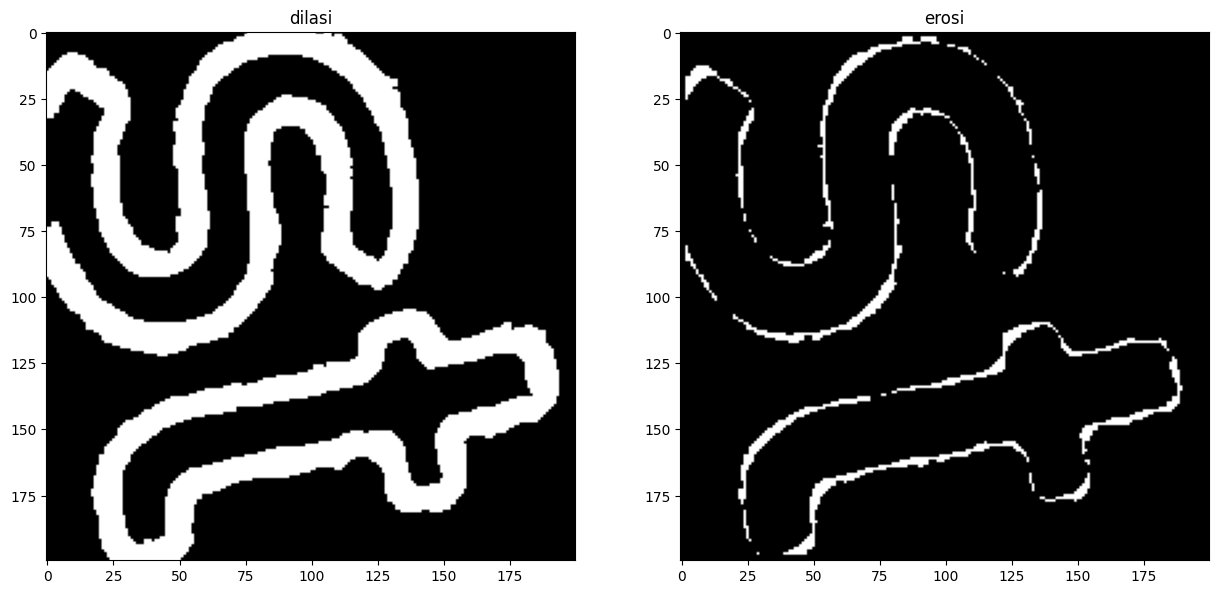

In [62]:
dil = dilasi(trasholdd, kernell)
eros = erosi(trasholdd, kernell)

plt.figure(figsize=(15, 10))
tampil(dil, "dilasi", 1, 2, 1)
tampil(eros, "erosi", 1, 2, 2)


## Analisis Hasil Dilasi dan Erosi

Output menampilkan dua hasil operasi morfologi secara berdampingan:

### 1. Dilasi (`dil`)
Dilasi berfungsi untuk memperluas atau menebalkan area piksel putih. Setiap piksel putih pada citra input akan menyebarkan nilai 255 ke tetangganya sesuai bentuk kernel. Kernel yang digunakan berbentuk diagonal asimetris (5×5 dengan pola diagonal dari kanan-atas ke kiri-bawah). Ini menyebabkan perluasan tepi tidak merata ke semua arah, melainkan miring mengikuti bentuk kernel. Hasilnya adalah garis-garis tepi yang semula tipis akan menjadi lebih tebal dan tersambung, adapun celah-celah kecil yang terputus pada citra threshold akan menjadi tertutup.

### Erosi (`eros`)
Erosi berfungsi untuk mempersempit atau mengikis area piksel putih. Sebuah piksel hanya akan tetap putih jika semua piksel di bawah kernel yang bernilai 1 pada citra input juga bernilai 255. Karena kernel 5×5 dengan pola asimetris, persyaratan kecocokan yang ketat menyebabkan banyak piksel putih yang hilang, terutama pada area tepi yang tipis. Hasilnya: tepi-tepi yang semula tebal menjadi lebih tipis, titik-titik noise kecil yang terisolasi hilang, dan hanya struktur garis yang cukup tebal yang bertahan.

**Perbandingan:** Dilasi membuat objek tampak lebih besar atau tebal, sedangkan erosi membuatnya lebih kecil atau tipis. Kernel asimetris yang sama akan menghasilkan efek yang berbeda pada kedua operasi ini.


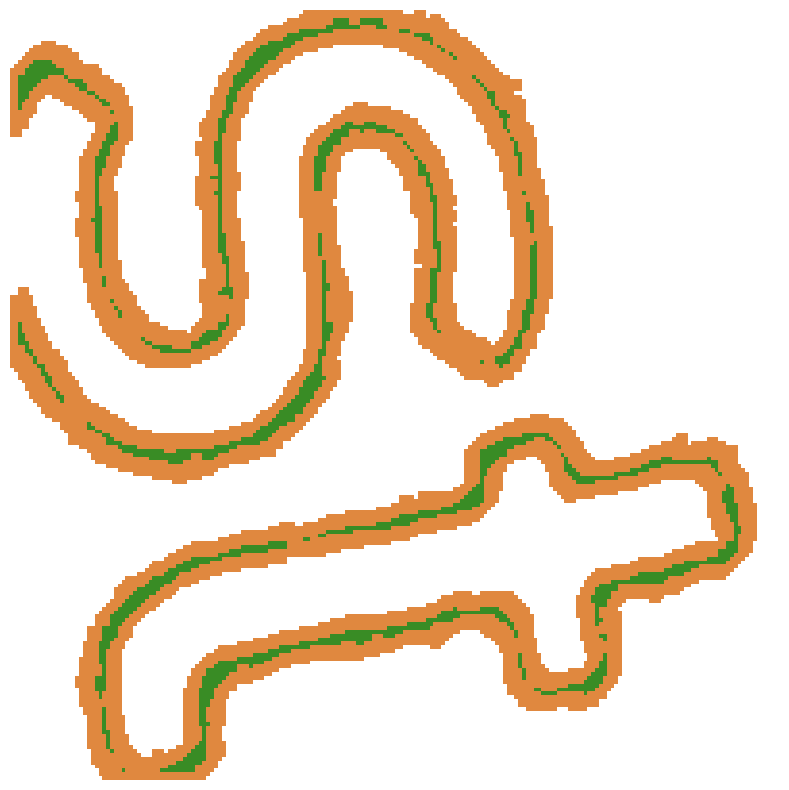

In [63]:
h, w = dil.shape
hasil_rgb = np.ones((h, w, 3), dtype=np.uint8) * 255

mask_dil = dil > 0
mask_eros = eros > 0

hasil_rgb[mask_dil] = [224, 136, 63]
hasil_rgb[mask_eros] = [57, 140, 37]

plt.figure(figsize=(15, 10))
plt.imshow(hasil_rgb)
plt.axis('off')
plt.show()

## Analisis Visualisasi Overlap Dilasi dan Erosi (RGB)

Output menampilkan overlay berwarna yang memperlihatkan perbedaan dan persamaan antara hasil dilasi dan erosi. Pertama ada latar putih  yang merupakan area yang tidak terdeteksi tepi baik oleh dilasi maupun erosi, merupakan area homogen pada citra asli. Warna oranye `[224, 136, 63]` (`mask_dil`)adalah area yang terdeteksi sebagai tepi oleh dilasi. Ini mencakup area yang cukup luas karena dilasi memperlebar tepi. Warna hijau `[57, 140, 37]` (`mask_eros`) adalah area yang terdeteksi oleh erosi. Area ini lebih sempit atau sedikit karena erosi mengikis banyak piksel tepi yang tidak memenuhi syarat kernel.

Adapun alasan mengapa warna hijau (erosi) terlihat lebih sedikit dari oranye (dilasi) adalah karena logika penulisan kodenya itu menimpa (`overwrite`). `hasil_rgb[mask_dil]` diterapkan lebih dulu (oranye), lalu barulah `hasil_rgb[mask_eros]` menimpa sebagian area oranye menjadi hijau. Artinya, area hijau adalah irisan (overlap) antara dilasi dan erosi, yaitu piksel yang terdeteksi oleh kedua operasi sekaligus. Area yang hanya berwarna oranye adalah piksel yang hanya ada di hasil dilasi (termasuk saat dilasi memperluas ke area yang dierosi). Visualisasi ini berguna untuk membandingkan secara intuitif seberapa besar perbedaan antara hasil dilasi dan erosi menggunakan kernel yang sama.
